ACT Math Performance Analysis

This project analyzes student ACT math performance and investigates how low-effort test-taking behavior impacts overall performance metrics.

In [30]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

df = pd.read_excel("assessment-report-20260417-ACT Assessment #2.xlsx")

Saving assessment-report-20260417-ACT Assessment #2.xlsx to assessment-report-20260417-ACT Assessment #2 (1).xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Data Cleaning

To ensure student privacy and comply with FERPA guidelines, all personally identifiable information (PII), including student names and IDs, was removed prior to analysis.

In [31]:
# Remove personally identifiable information (PII) to comply with FERPA
df = df.drop(columns=["student_id", "first_name", "last_name"])

# Create anonymous student IDs
df["student_uid"] = range(1, len(df) + 1)

# Move anonymous student ID to the front for readability
column_order = ["student_uid"] + [column for column in df.columns if column != "student_uid"]
df = df[column_order]

df.head()

,student_uid,grade_level,assessment_name,assessment_date_english,time_spent_english,assessment_date_math,time_spent_math,assessment_date_reading,time_spent_reading,assessment_date_science,time_spent_science,timed_untimed,total_scaled_score,english_scaled_score,english_questions_correct,grammar_percent_correct,sentence_structure_percent_correct,punctuation_percent_correct,writing_strategy_percent_correct,organization_percent_correct,style_percent_correct,math_scaled_score,math_questions_correct,pre_algebra_percent_correct,elementary_algebra_percent_correct,intermediate_algebra_percent_correct,coordinate_geometry_percent_correct,plane_geometry_percent_correct,reading_scaled_score,reading_questions_correct,details_and_implicit_meaning_percent_correct,generalizations_and_main_ideas_percent_correct,author_s_voice_and_method_percent_correct,meanings_of_words_and_phrases_percent_correct,relationships_percent_correct,science_scaled_score,science_questions_correct,understanding_questions_percent_correct,analysis_questions_percent_correct,synthesis_questions_percent_correct,experimental_design_percent_correct,knowledge_questions_percent_correct,national_percentile_ranking_overall,national_percentile_ranking_english,national_percentile_ranking_math,national_percentile_ranking_reading,national_percentile_ranking_science,section_completion_english,section_completion_math,section_completion_reading,section_completion_science
0,1,12,ACT Assessment #2,2026-01-16 08:50:10,00:34:17,2026-01-13 08:58:27,00:41:58,2026-01-12 08:27:08,00:08:20,2026-01-15 08:34:15,00:18:17,Timed,17,21.0,29.0,88.9,50.0,75.0,33.3,50.0,60.0,16.0,16.0,42.9,44.4,33.3,33.3,29.4,14.0,10.0,28.6,33.3,66.7,22.2,14.3,15.0,10.0,30.0,30.0,8.3,40.0,33.3,35,60.0,33.0,19.0,19.0,Completed,Completed,Completed,Completed
1,2,12,ACT Assessment #2,2026-01-16 08:20:31,00:03:20,2026-01-13 08:26:30,00:11:56,2026-01-12 08:30:54,00:10:22,NaT,NaN,Timed,14,18.0,21.0,55.6,62.5,25.0,44.4,10.0,50.0,10.0,10.0,14.3,11.1,11.1,66.7,29.4,15.0,11.0,35.7,33.3,33.3,11.1,42.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,45.0,1.0,24.0,NaN,Completed,Completed,Completed,NaN
2,3,11,ACT Assessment #2,2026-01-16 08:46:57,00:32:11,2026-01-13 09:07:42,00:49:38,2026-01-12 08:57:20,00:37:01,2026-01-15 08:53:46,00:37:16,Timed,19,20.0,24.0,66.7,37.5,50.0,33.3,50.0,50.0,15.0,15.0,28.6,22.2,44.4,66.7,29.4,22.0,21.0,64.3,66.7,33.3,55.6,57.1,21.0,14.0,40.0,40.0,33.3,20.0,33.3,47,55.0,21.0,61.0,58.0,Completed,Completed,Completed,Completed
3,4,12,ACT Assessment #2,2026-01-16 08:28:41,00:14:49,2026-01-13 08:33:05,00:20:04,2026-01-12 08:36:14,00:17:40,2026-01-15 08:23:47,00:12:03,Timed,26,26.0,39.0,100.0,100.0,75.0,55.6,60.0,80.0,25.0,30.0,85.7,77.8,77.8,33.3,52.9,28.0,31.0,92.9,66.7,66.7,77.8,100.0,26.0,20.0,40.0,60.0,58.3,20.0,66.7,82,82.0,79.0,82.0,85.0,Completed,Completed,Completed,Completed
4,5,11,ACT Assessment #2,2026-01-16 08:50:06,00:34:48,2026-01-13 09:04:58,00:46:41,2026-01-12 08:52:01,00:30:08,2026-01-15 08:48:41,00:31:45,Timed,13,12.0,13.0,22.2,25.0,25.0,33.3,20.0,30.0,10.0,10.0,14.3,33.3,22.2,0.0,23.5,16.0,12.0,14.3,100.0,0.0,44.4,42.9,14.0,9.0,40.0,10.0,25.0,0.0,33.3,10,15.0,1.0,29.0,14.0,Completed,Completed,Completed,Completed


In [32]:
pd.set_option('display.max_columns', None)
df.describe()

,student_uid,grade_level,assessment_date_english,assessment_date_math,assessment_date_reading,assessment_date_science,total_scaled_score,english_scaled_score,english_questions_correct,grammar_percent_correct,sentence_structure_percent_correct,punctuation_percent_correct,writing_strategy_percent_correct,organization_percent_correct,style_percent_correct,math_scaled_score,math_questions_correct,pre_algebra_percent_correct,elementary_algebra_percent_correct,intermediate_algebra_percent_correct,coordinate_geometry_percent_correct,plane_geometry_percent_correct,reading_scaled_score,reading_questions_correct,details_and_implicit_meaning_percent_correct,generalizations_and_main_ideas_percent_correct,author_s_voice_and_method_percent_correct,meanings_of_words_and_phrases_percent_correct,relationships_percent_correct,science_scaled_score,science_questions_correct,understanding_questions_percent_correct,analysis_questions_percent_correct,synthesis_questions_percent_correct,experimental_design_percent_correct,knowledge_questions_percent_correct,national_percentile_ranking_overall,national_percentile_ranking_english,national_percentile_ranking_math,national_percentile_ranking_reading,national_percentile_ranking_science
count,104.000000,104.000000,96,100,96,100,104.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,100.000000,100.000000,100.000000,100.0000,100.000000,100.000000,100.000000,104.000000,96.000000,100.000000,96.000000,100.000000
mean,52.500000,11.432692,2026-01-16 08:40:09.166666496,2026-01-13 10:19:09.669999872,2026-01-12 15:19:39.598166784,2026-01-15 08:59:43.069999872,19.403846,19.770833,26.041667,68.183333,50.260417,53.906250,41.889583,50.312500,49.270833,18.050000,19.690000,49.005000,46.218000,44.329000,50.674000,38.765,20.656250,18.812500,51.862500,50.700000,65.976042,51.504167,48.810417,21.500000,15.280000,45.600000,40.4000,32.332000,34.600000,35.655000,47.884615,53.604167,42.430000,51.916667,58.640000
min,1.000000,11.000000,2026-01-16 08:18:19,2026-01-13 08:23:54,2026-01-12 08:27:08,2026-01-15 08:19:27,10.000000,6.000000,7.000000,0.000000,0.000000,0.000000,0.000000,10.000000,0.000000,6.000000,6.000000,0.000000,0.000000,0.000000,0.000000,5.900,9.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,5.000000,0.000000,0.0000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,3.000000
25%,26.750000,11.000000,2026-01-16 08:36:00,2026-01-13 08:49:10,2026-01-12 08:44:12.249999872,2026-01-15 08:40:42.500000,16.000000,17.000000,19.000000,55.600000,25.000000,43.750000,22.200000,30.000000,40.000000,14.000000,14.000000,28.600000,22.200000,22.200000,33.300000,29.400,16.750000,12.750000,41.100000,33.300000,33.300000,33.300000,28.600000,18.500000,11.750000,30.000000,30.0000,16.700000,20.000000,33.300000,28.000000,41.000000,11.000000,32.750000,41.750000
50%,52.500000,11.000000,2026-01-16 08:42:04,2026-01-13 08:56:23,2026-01-12 08:52:37.500000,2026-01-15 08:47:21,19.000000,21.000000,27.000000,66.700000,50.000000,50.000000,38.850000,50.000000,50.000000,18.000000,18.000000,42.900000,44.400000,44.400000,66.700000,38.250,21.000000,18.500000,50.000000,66.700000,66.700000,55.600000,42.900000,22.000000,15.000000,50.000000,40.0000,33.300000,40.000000,33.300000,47.000000,60.000000,49.000000,55.000000,64.000000
75%,78.250000,12.000000,2026-01-16 08:46:58,2026-01-13 09:03:32.249999872,2026-01-12 08:58:52.750000128,2026-01-15 08:52:00.249999872,23.000000,22.250000,32.250000,88.900000,75.000000,75.000000,55.600000,70.000000,60.000000,22.000000,25.000000,71.400000,66.700000,66.700000,66.700000,47.100,24.250000,24.250000,64.300000,66.700000,100.000000,77.800000,71.400000,25.000000,18.000000,60.000000,52.5000,41.700000,60.000000,33.300000,70.000000,66.500000,65.000000,71.750000,82.000000
max,104.000000,12.000000,2026-01-16 08:51:45,2026-01-16 08:3

In [33]:
df["time_spent_math"].describe()

,time_spent_math
count,100
unique,98
top,00:33:50
freq,2


In [34]:
# Convert time columns from string to timedelta for analysis
time_columns = [
    "time_spent_english",
    "time_spent_math",
    "time_spent_reading",
    "time_spent_science"
]

df[time_columns] = df[time_columns].apply(pd.to_timedelta)
df["time_spent_math"].describe()

,time_spent_math
count,100
mean,0 days 00:35:50.500000
std,0 days 00:12:08.356105323
min,0 days 00:01:25
25%,0 days 00:29:14.250000
50%,0 days 00:39:16.500000
75%,0 days 00:45:49
max,0 days 00:49:46


Identifying Low-Effort Students

Students were classified as low-effort if they completed the math section unusually quickly while also performing poorly. This approach helps distinguish between high-performing fast test-takers and students who may have disengaged from the test.

A threshold of 20 minutes was selected based on the observed distribution of completion times, as it falls well below the typical testing duration, while the 25th percentile cutoff captures students performing significantly below average.

In [35]:
# Flag likely low-effort students (fast AND low performance)
df["low_effort_math"] = (
    (df["time_spent_math"] < pd.Timedelta(minutes=20)) &
    (df["national_percentile_ranking_math"] < 25)
)
df["low_effort_math"].value_counts()

,count
low_effort_math,
False,92
True,12


In [36]:
# Average score including all students
overall_avg = df["national_percentile_ranking_math"].mean()

# Average score excluding low-effort students
filtered_avg = df[~df["low_effort_math"]]["national_percentile_ranking_math"].mean()

float(overall_avg), float(filtered_avg)

(42.43, 47.67045454545455)

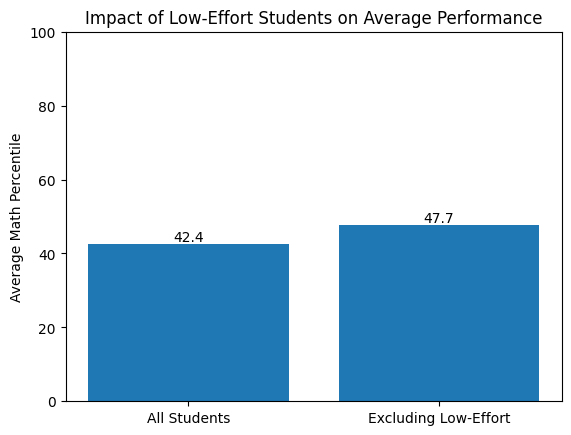

In [39]:
import matplotlib.pyplot as plt

labels = ["All Students", "Excluding Low-Effort"]
values = [overall_avg, filtered_avg]

plt.figure()
bars = plt.bar(labels, values)

plt.ylabel("Average Math Percentile")
plt.title("Impact of Low-Effort Students on Average Performance")

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.1f}",
             ha='center', va='bottom')

plt.ylim(0, 100)

plt.show()

In [38]:
df[["time_spent_math", "national_percentile_ranking_math"]].corr()

,time_spent_math,national_percentile_ranking_math
time_spent_math,1.000000,0.440442
national_percentile_ranking_math,0.440442,1.000000


By identifying students with unusually low completion times and low performance, I found that approximately 12% of students reduced the overall average math percentile by over 5 points. This suggests that disengaged test-taking behavior can meaningfully distort aggregate performance metrics used to evaluate school outcomes.

Given this impact, it may be valuable to analyze results both with and without these students when developing curriculum improvement plans, while separately addressing student engagement at the administrative level.

Limitations

*   The definition of “low-effort” is based on a proxy (time spent and performance) and may not perfectly identify all disengaged students.
*   Time spent on a test does not fully capture student effort or ability, as some students may work quickly and accurately while others may take longer but still struggle.